<a href="https://colab.research.google.com/github/haniyawahabb/PCA-Principal-Component-Analysis-/blob/main/PCA_(Principal_Component_Analysis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
X = df.iloc[:, 2:5]
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_scaled = sc.fit_transform(X)

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [ ]:
X_pca.shape

(200, 2)

In [ ]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.44266167 0.33308378]


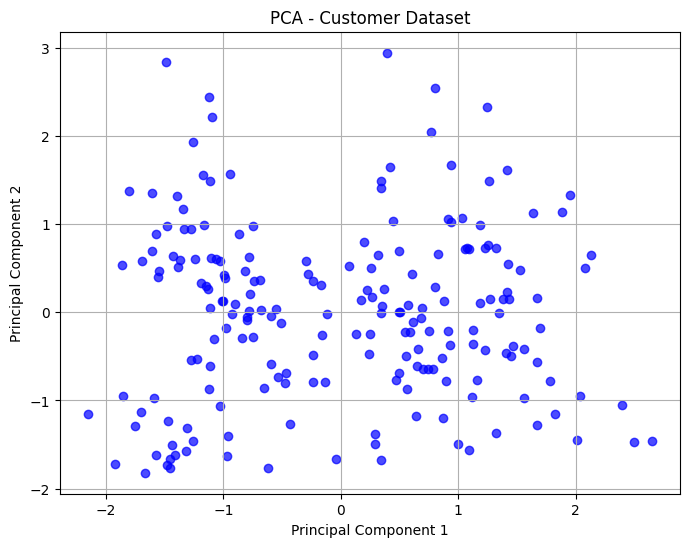

In [ ]:
principal_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# Scatter Plot of PCA Components

plt.figure(figsize=(8,6))

plt.scatter(
    principal_df["PC1"],
    principal_df["PC2"],
    c='blue',
    alpha=0.7
)

plt.title("PCA - Customer Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

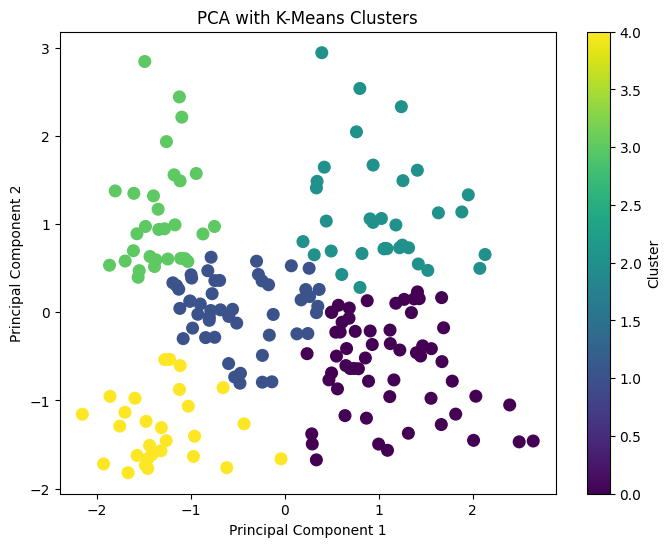

In [ ]:
from sklearn.cluster import KMeans

# Initialize KMeans with a chosen number of clusters, for example 5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X_pca)

# Add Cluster Labels
principal_df["Cluster"] = kmeans.labels_

plt.figure(figsize=(8,6))

plt.scatter(
    principal_df["PC1"],
    principal_df["PC2"],
    c=principal_df["Cluster"],
    cmap="viridis",
    s=70
)

plt.title("PCA with K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

Conclusion

PCA successfully reduced the dimensionality of the dataset while retaining most of the important information. The transformed data can be visualized in two dimensions without significant information loss. PCA is especially useful as a preprocessing step before applying clustering or classification algorithms, as it improves efficiency and simplifies analysis.